In [1]:
!pip install git+https://github.com/OpenHydrology/lmoments3.git

  Cloning https://github.com/OpenHydrology/lmoments3.git to /tmp/pip-req-build-s0_mzpoy
  Running command git clone -q https://github.com/OpenHydrology/lmoments3.git /tmp/pip-req-build-s0_mzpoy


In [38]:
# import packages

import requests 
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

import lmoments3 as lm
from lmoments3 import distr

import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# import cal-adapt analytics engine package
import climakit_alpha as ck 

## 1. Select

### Choose a location, variables, scenarios, and designate warming levels of interest:

In [7]:
ds = xr.open_dataset("tas_Amon_NorESM1-M_historical_r1i1p1_185001-200512.nc")
ds

<xarray.Dataset>
Dimensions:    (time: 1872, bnds: 2, lat: 96, lon: 144)
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2005-12-16 12:00:00
  * lat        (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon        (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height     float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    lat_bnds   (lat, bnds) float64 ...
    lon_bnds   (lon, bnds) float64 ...
    tas        (time, lat, lon) float32 ...
Attributes: (12/26)
    institution:            Norwegian Climate Centre
    institute_id:           NCC
    experiment_id:          historical
    source:                 NorESM1-M 2011  atmosphere: CAM-Oslo (CAM4-Oslo-n...
    model_id:               NorESM1-M
    forcing:                GHG, SA, Oz, Sl, Vl, BC, OC
    ...                     ...
    table_id:               Table Amon (27 April 2011) a5a1c518f52ae340313ba0...
    title:                  NorESM1-M model output prepared for CMIP5 historical
    parent_experiment:      pre-industrial control
    modeling_realm:         atmos
    realization:            1
    cmor_version:           2.6.0

In [8]:
ds['tas'].data = ds['tas'].data - 273.15
ds['tas'].data = ds['tas'].data * (9/5) + 32
ds['tas'].attrs['units'] = 'F' 

In [17]:
da = ds.tas
da

<xarray.DataArray 'tas' (time: 1872, lat: 96, lon: 144)>
array([[[-26.09562  , -25.560062 , -24.417953 , ..., -25.568878 ,
         -26.768753 , -26.853813 ],
        [-21.15298  , -22.623005 , -22.773903 , ..., -20.67329  ,
         -21.146774 , -22.306519 ],
        [-16.14066  , -16.60736  , -17.41631  , ..., -16.316113 ,
         -15.296085 , -16.233467 ],
        ...,
        [-27.338696 , -27.701656 , -27.880844 , ..., -26.580338 ,
         -26.776058 , -27.004242 ],
        [-30.437195 , -30.610699 , -30.783459 , ..., -30.11428  ,
         -30.204533 , -30.307201 ],
        [-32.727737 , -32.707    , -32.70571  , ..., -32.784454 ,
         -32.76465  , -32.7555   ]],

       [[-43.910034 , -43.514114 , -41.942764 , ..., -43.587997 ,
         -44.180656 , -44.330452 ],
        [-39.7862   , -41.305557 , -41.638634 , ..., -39.258064 ,
         -39.746185 , -40.903847 ],
        [-33.62661  , -34.050926 , -34.82937  , ..., -33.32067  ,
         -32.76641  , -33.57904  ],
...
        [-23.33363  , -23.123516 , -22.956139 , ..., -23.934086 ,
         -23.751549 , -23.567226 ],
        [-22.787445 , -22.759842 , -22.711666 , ..., -22.804611 ,
         -22.800629 , -22.794476 ],
        [-22.835892 , -22.820404 , -22.812904 , ..., -22.944    ,
         -22.89618  , -22.85891  ]],

       [[-23.020271 , -23.019089 , -22.851685 , ..., -22.828175 ,
         -23.082703 , -22.965942 ],
        [-21.113266 , -20.822071 , -21.645111 , ..., -20.474628 ,
         -20.79359  , -20.83891  ],
        [-14.783768 , -15.698982 , -15.880283 , ..., -13.559807 ,
         -14.224342 , -14.645584 ],
        ...,
        [-15.215282 , -14.894455 , -14.627293 , ..., -16.329407 ,
         -15.996273 , -15.620514 ],
        [-16.874847 , -16.745651 , -16.622135 , ..., -17.245804 ,
         -17.125061 , -17.001274 ],
        [-19.763016 , -19.771038 , -19.781311 , ..., -19.870956 ,
         -19.811138 , -19.774033 ]]], dtype=float32)
Coordinates:
  * time     (time) object 1850-01-16 12:00:00 ... 2005-12-16 12:00:00
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
    height   float64 2.0
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    units:             F
    original_name:     TREFHT
    cell_methods:      time: mean
    cell_measures:     area: areacella
    history:           2011-06-01T03:52:41Z altered by CMOR: Treated scalar d...
    associated_files:  baseURL: http://cmip-pcmdi.llnl.gov/CMIP5/dataLocation...

In [18]:
test = da.isel(lon=3,lat=3)
ams = test.groupby('time.year').max('time')
ams

<xarray.DataArray 'tas' (year: 156)>
array([-15.39133835, -17.51565552, -15.76135635, -14.91815567,
       -17.65081406, -16.304245  , -16.32185364, -16.09023285,
       -11.75972366, -10.79501724, -18.17579651, -10.4234848 ,
       -17.0592804 , -18.49777603, -16.23994827, -17.00404739,
       -13.94358826, -13.97662735, -14.06998444, -15.08929443,
       -15.62108994, -17.25453568, -12.81419373, -13.84440613,
       -12.99337769, -16.17095566, -14.89225769, -11.98939514,
       -18.66300964, -14.5176239 , -16.85985184, -17.94747162,
       -14.60586929, -12.46957779,  -8.96139908, -17.27197647,
       -12.04885864, -16.41627884, -17.86100769, -17.37958908,
       -11.27624512, -14.28083801, -12.84833145, -13.3624382 ,
       -12.8122406 , -14.02557373, -10.99026871, -14.17449188,
       -15.9937439 , -12.08055115, -15.64803314, -13.94413757,
       -12.32085037, -14.42269897, -18.00712585, -17.31490707,
       -15.03332138, -11.79581451, -14.0995369 , -14.30792236,
        -9.90226746, -14.89472961, -15.71971893, -18.93811035,
       -14.45272064, -12.89782715, -18.77254486, -15.00574493,
       -16.22959518, -17.13022614, -19.50599289, -16.82689285,
       -17.42809296, -18.25022888, -15.43712234, -14.56071472,
       -12.52901459, -14.81752014, -15.58280182, -17.58143616,
       -18.31251907, -17.50559998, -17.9101181 , -15.07877731,
       -14.78335571, -14.73580933, -14.55632019, -13.45461273,
       -13.66500092, -13.46900558, -17.18463516, -13.92922211,
       -18.89377975, -15.81192017, -14.59323502, -16.34728622,
       -18.76847839, -15.60081863, -15.65874481, -14.44319153,
       -17.17985535, -18.34144211, -17.5953331 , -14.62366867,
       -14.92461014, -15.510952  , -17.36286163, -12.46804047,
       -14.36460876, -12.72657776, -14.39729309, -14.39721298,
       -13.79499817, -15.93087769, -14.97850037, -12.90658569,
       -15.33734131, -15.48109436, -16.65625   , -14.52915955,
       -12.02776337, -13.88516617, -16.05584717, -13.9683075 ,
       -15.47947693, -14.32777786, -14.36048889, -15.21772766,
       -11.76398087,  -9.82368851, -15.66563797, -15.75671387,
       -14.79560471, -11.14393997, -16.15538025, -16.83752441,
       -13.37702179, -13.97618866, -16.94035339, -15.47804642,
       -11.87109756, -13.72528839, -15.8979187 , -13.35040665,
       -14.15534973, -14.17086792, -14.21868515, -15.70406342,
       -12.07102203, -13.50926971, -11.21172714, -10.61159897,
       -10.41420364, -15.20976257, -15.18921661, -11.17132568])
Coordinates:
    lat      float64 -84.32
    lon      float64 7.5
    height   float64 2.0
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2001 2002 2003 2004 2005

In [19]:
paras = distr.gev.lmom_fit(ams)
fitted_gev = distr.gev(**paras)

In [20]:
return_year = 10
return_period = 1.0-(1./return_year)

threshold = fitted_gev.ppf(return_period)
threshold = round(threshold, 5)

for a 1 in a 10 year event, a -11.9654 (m) precipitation event is expected


In [24]:
def getThreshold(y, return_year=10):
    ams = y.groupby('time.year').max('time')
    paras = distr.gev.lmom_fit(ams)
    fitted_gev = distr.gev(**paras)
    return_period = 1.0-(1./return_year)
    
    threshold = fitted_gev.ppf(return_period)
    threshold = round(threshold, 5)
    return xr.DataArray(threshold)

In [22]:
stacked = da.stack(allpoints=['lon','lat']).squeeze()
stacked

<xarray.DataArray 'tas' (time: 1872, allpoints: 13824)>
array([[-26.09562  , -21.15298  , -16.14066  , ..., -27.004242 ,
        -30.307201 , -32.7555   ],
       [-43.910034 , -39.7862   , -33.62661  , ..., -33.959465 ,
        -35.60714  , -37.442078 ],
       [-65.984146 , -60.986908 , -53.400955 , ..., -28.044895 ,
        -27.908749 , -27.802181 ],
       ...,
       [-50.491417 , -53.67408  , -51.047905 , ...,  -7.7992363,
         -7.8505707,  -8.34589  ],
       [-36.642303 , -37.74415  , -34.18595  , ..., -23.567226 ,
        -22.794476 , -22.85891  ],
       [-23.020271 , -21.113266 , -14.783768 , ..., -15.620514 ,
        -17.001274 , -19.774033 ]], dtype=float32)
Coordinates:
  * time       (time) object 1850-01-16 12:00:00 ... 2005-12-16 12:00:00
    height     float64 2.0
  * allpoints  (allpoints) MultiIndex
  - lon        (allpoints) float64 0.0 0.0 0.0 0.0 ... 357.5 357.5 357.5 357.5
  - lat        (allpoints) float64 -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    units:             F
    original_name:     TREFHT
    cell_methods:      time: mean
    cell_measures:     area: areacella
    history:           2011-06-01T03:52:41Z altered by CMOR: Treated scalar d...
    associated_files:  baseURL: http://cmip-pcmdi.llnl.gov/CMIP5/dataLocation...

In [25]:
output = stacked.groupby('allpoints').apply(getThreshold)
output

<xarray.DataArray (allpoints: 13824)>
array([-21.52196, -19.04682, -14.49626, ...,  30.83104,  30.99342,
        31.03297])
Coordinates:
    height     float64 2.0
  * allpoints  (allpoints) MultiIndex
  - lon        (allpoints) float64 0.0 0.0 0.0 0.0 ... 357.5 357.5 357.5 357.5
  - lat        (allpoints) float64 -90.0 -88.11 -86.21 ... 86.21 88.11 90.0

In [26]:
unstack = output.unstack('allpoints')

In [36]:
data = unstack.transpose()
data

<xarray.DataArray (lat: 96, lon: 144)>
array([[-21.52196, -20.97712, -21.34279, ..., -20.9461 , -21.64477,
        -21.45821],
       [-19.04682, -18.87176, -19.98487, ..., -18.49348, -18.85462,
        -19.22249],
       [-14.49626, -14.6858 , -15.28713, ..., -13.42246, -13.94315,
        -14.44187],
       ...,
       [ 30.83551,  30.84004,  30.83867, ...,  30.82064,  30.82775,
         30.83104],
       [ 30.99295,  30.99336,  30.9949 , ...,  30.99419,  30.99316,
         30.99342],
       [ 31.03347,  31.03432,  31.03492, ...,  31.03391,  31.03329,
         31.03297]])
Coordinates:
    height   float64 2.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0

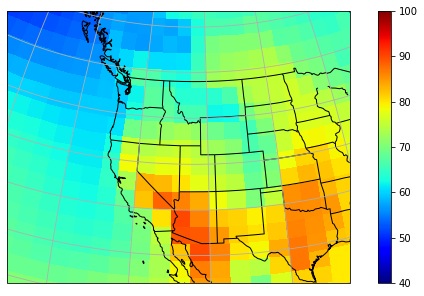

In [55]:
fig = plt.figure(figsize=[10,5])
ax = plt.subplot(111,projection=ccrs.Orthographic(-112,42))
plotted = ax.pcolormesh(data.lon,data.lat,data,transform=ccrs.PlateCarree(),cmap=cm.jet,
                       vmin=40,vmax=100)
ax.set_extent([-135,-93,25,55])
ax.coastlines() 
ax.gridlines()
fig.colorbar(plotted)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.NaturalEarthFeature(category='cultural',
                                    name='admin_1_states_provinces_lines',
                                    scale='110m',facecolor='None'),edgecolor='k')

## 2. Generate

### Convert time series into annual max series (AMS)

In [ ]:
ams = ck.get_ams(ds, temp)

### Fit AMS to a generalized extreme value distribution (GEV)

In [ ]:
fit = ck.fit_gev(ams)

## 3. Calculate Return Values & Exceedance Probability

### Get value of a 1 in 10 year event

In [ ]:
ck.get_return_value(10)

### Get probability of a certain temperature being exceeded

In [ ]:
ck.get_exceedance(105)

## 4. Visualize

### Produce plots of exceedance probabilities

In [ ]:
ck.plot(exceedance)

## 5. Export

### Download processed data

In [ ]:
ck.export()